# Loan Default Prediction

In [1]:
%load_ext autoreload
%autoreload 2

from scripts.utilities import *
from scripts.features import *

## 1. Load and Process Data

In [2]:
# Load raw data
consumer_df, account_df, transaction_df = get_data()

# Filter unknown consumers
consumer_df, account_df, transaction_df = filter_unknown(consumer_df, account_df, transaction_df)

Data successfully loaded and processed.


In [3]:
# Define feature functions
selected_features = [
    average_transaction_amount,
    net_monthly_cash_flow,
    average_account_balance,
    time_based_average_transaction_amounts,
    descriptive_stats_by_category,
    outflow_stats,
    outflow_over_time_fix,
    balance_over_time
]

# Calculate features
feature_dataframes = execute_selected_features(selected_features, account_df, transaction_df)
final_features = merge_features(feature_dataframes)

# Merge with consumer data
ml_features = consumer_df.merge(final_features, how="left", on="prism_consumer_id")
ml_features = ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)


Feature Execution Plan:
- Total feature creation functions: 8
- Updated features (1): outflow_over_time_fix
- Unchanged feature creation functions: 7 (using cached results)

Executing features...
- Running outflow_over_time_fix...
- Using cached result for average_transaction_amount
- Using cached result for net_monthly_cash_flow
- Using cached result for average_account_balance
- Using cached result for time_based_average_transaction_amounts
- Using cached result for descriptive_stats_by_category
- Using cached result for outflow_stats
- Using cached result for balance_over_time

Total Created Features:  258


## 2 Split Data

In [4]:
# Split with validation set for hyperparameter tuning
train_df, _, test_df = split_data(ml_features, test_size=0.25)

# Define feature columns
exclude_columns = ['prism_consumer_id', 'evaluation_date', 'credit_score', 'DQ_TARGET']
all_feature_columns = [col for col in train_df.columns if col not in exclude_columns]

Training set size: 7591
No validation set created.
Test set size: 2531


## 3. Feature Selection

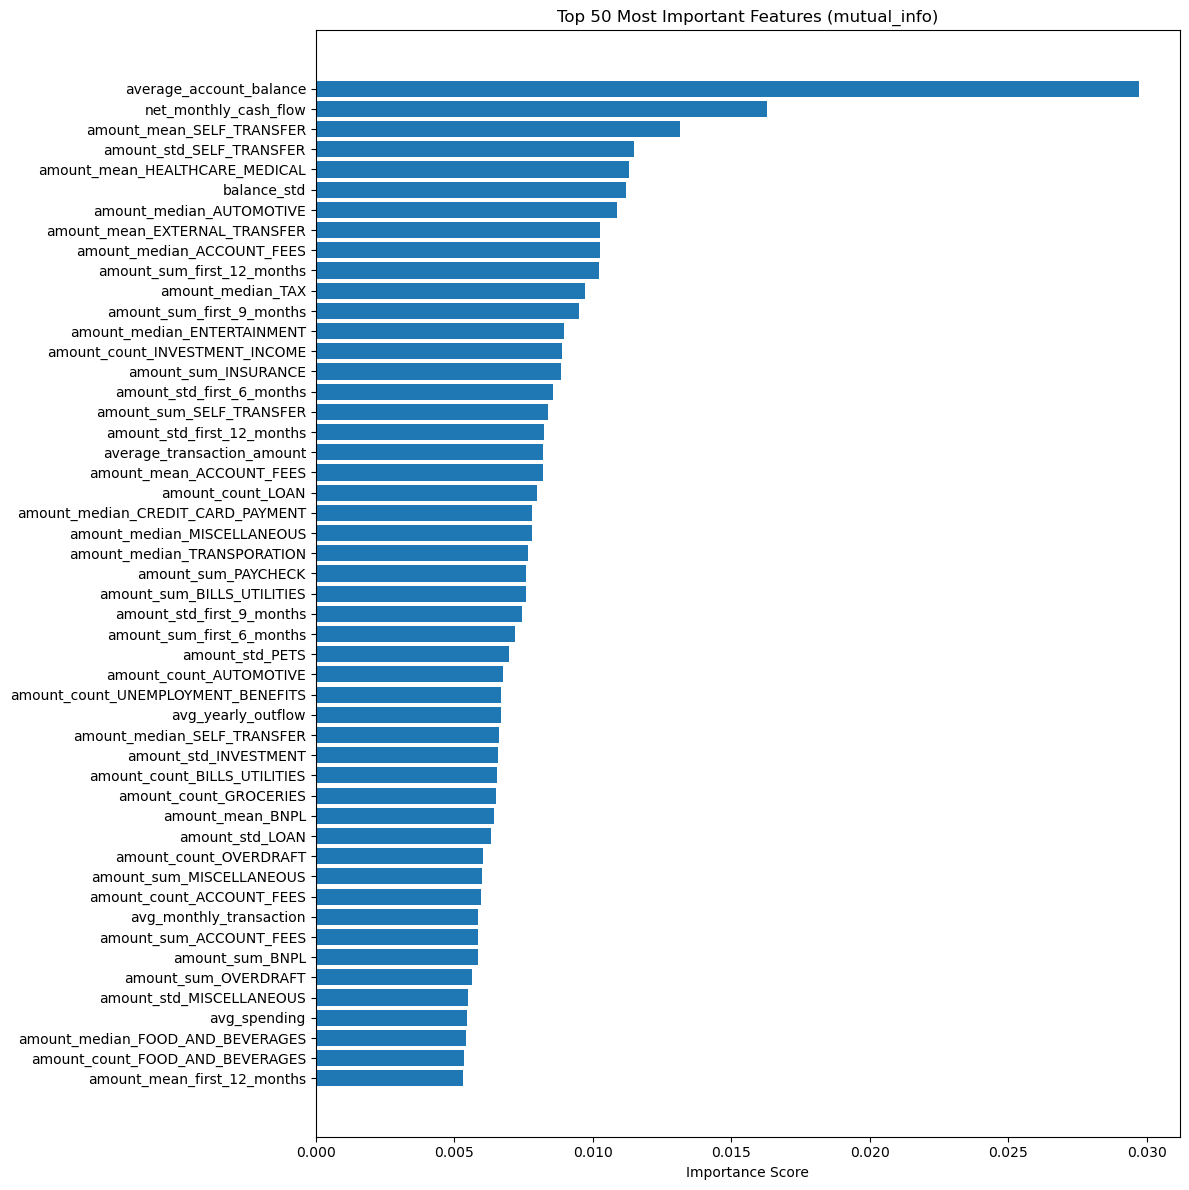

In [5]:
# Initialize the feature selector with your training DataFrame, feature columns, and any forced features.
fs = FeatureSelector(train_df, all_feature_columns)

# Run feature selection using the desired method(s)
# available --> ['mutual_info', 'random_forest', 'xgboost']
fs.run_feature_selection(methods=['mutual_info'], n_features=50)

# Retrieve the selected features for a given method
feature_columns = fs.get_selected_features('mutual_info')

# Plot the importance scores for the selected method
fs.plot_feature_importance('mutual_info', top_n=50)

## 4. Model Performance

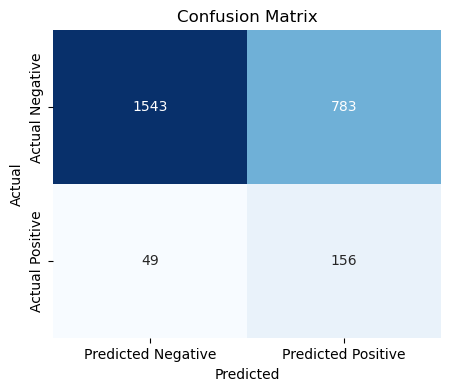

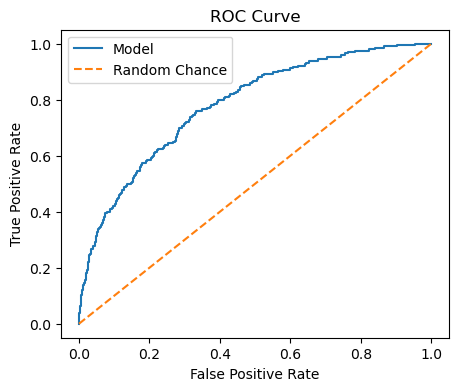

=== TEST METRICS ===
Accuracy: 0.6712761754247333
ROC AUC Score: 0.7804479583918797
Balanced Accuracy: 0.7121731015246524
Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.66      0.79      2326
         1.0       0.17      0.76      0.27       205

    accuracy                           0.67      2531
   macro avg       0.57      0.71      0.53      2531
weighted avg       0.90      0.67      0.75      2531

=== TRAINING METRICS ===
Train Accuracy: 0.7103148465287841
Train ROC AUC: 0.9295708994075732
Train Balanced Accuracy: 0.8310942512287606


In [6]:
# Initialize and train model with all features
model, scaler = train_model(train_df, all_feature_columns, "xgboost")
predict_and_analyze_model(model, scaler, train_df, test_df, all_feature_columns)

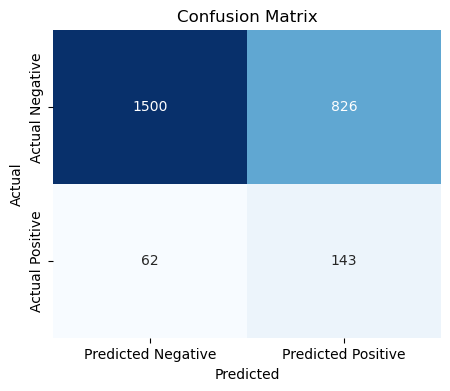

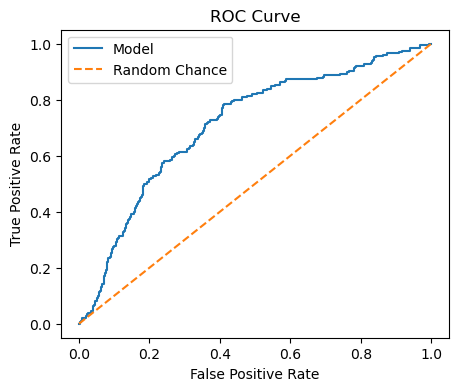

=== TEST METRICS ===
Accuracy: 0.6491505333860135
ROC AUC Score: 0.7104334878258499
Balanced Accuracy: 0.6712224482519975
Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.64      0.77      2326
         1.0       0.15      0.70      0.24       205

    accuracy                           0.65      2531
   macro avg       0.55      0.67      0.51      2531
weighted avg       0.89      0.65      0.73      2531

=== TRAINING METRICS ===
Train Accuracy: 0.6701356869977605
Train ROC AUC: 0.8030892296522907
Train Balanced Accuracy: 0.7361954872450467


In [7]:
# Initialize and train model with all features
model, scaler = train_model(train_df, all_feature_columns, "logistic")
predict_and_analyze_model(model, scaler, train_df, test_df, all_feature_columns)

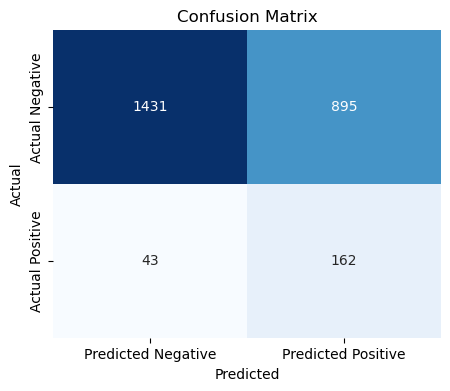

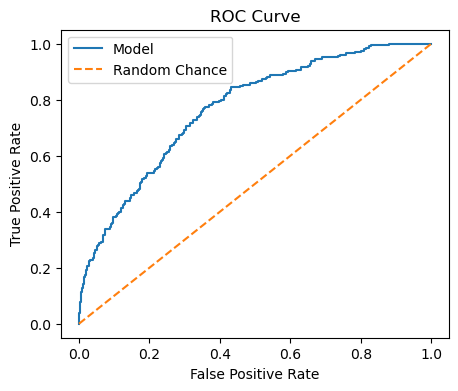

=== TEST METRICS ===
Accuracy: 0.6293954958514422
ROC AUC Score: 0.7671434263783738
Balanced Accuracy: 0.7027315814860642
Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.62      0.75      2326
         1.0       0.15      0.79      0.26       205

    accuracy                           0.63      2531
   macro avg       0.56      0.70      0.50      2531
weighted avg       0.90      0.63      0.71      2531

=== TRAINING METRICS ===
Train Accuracy: 0.6723751811355553
Train ROC AUC: 0.9061528779367608
Train Balanced Accuracy: 0.7993198688094515


In [8]:
# Initialize and train model with best features
model, scaler = train_model(train_df, feature_columns, "xgboost")
predict_and_analyze_model(model, scaler, train_df, test_df, feature_columns)

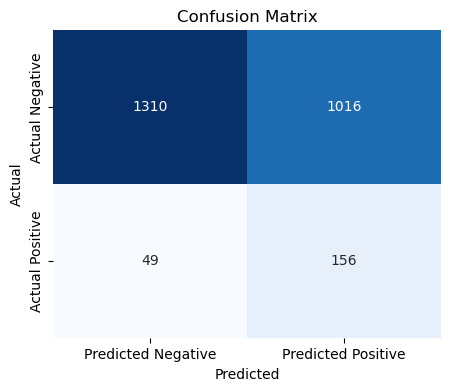

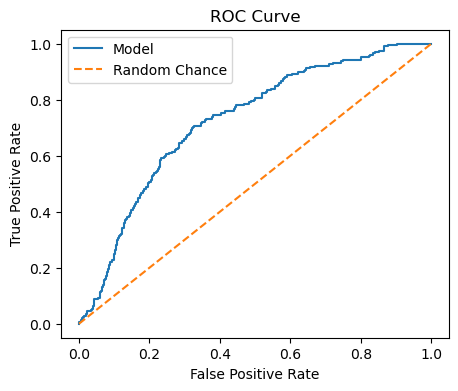

=== TEST METRICS ===
Accuracy: 0.579217700513631
ROC AUC Score: 0.723972904389405
Balanced Accuracy: 0.6620871170018665
Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.56      0.71      2326
         1.0       0.13      0.76      0.23       205

    accuracy                           0.58      2531
   macro avg       0.55      0.66      0.47      2531
weighted avg       0.90      0.58      0.67      2531

=== TRAINING METRICS ===
Train Accuracy: 0.6012383085232512
Train ROC AUC: 0.7513817665129154
Train Balanced Accuracy: 0.6936630107450513


In [9]:
# Initialize and train model with best features
model, scaler = train_model(train_df, feature_columns, "logistic")
predict_and_analyze_model(model, scaler, train_df, test_df, feature_columns)